In [1]:
import pandas as pd
import numpy as np
from tensordict import TensorDict
from math import ceil
import torch
import json
import pickle
import time
from datetime import datetime
import statistics
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import cycle
from rl4co.utils.ops import unbatchify, gather_by_index
import data_process

In [2]:
with open('3t_data/184d181a-0630-49a7-b8c5-2f94f634ee3e.json', 'r') as file:
    data = json.load(file)
data

{'multi_visit_penalty': False,
 'req_id': '184d181a-0630-49a7-b8c5-2f94f634ee3e',
 'directory_reference': '3cbdb0a0-e623-4ac6-ad7c-002b1405ced4',
 'col_date': '2026-03-04T00:00:00',
 'variant': 'vrptw',
 'biggest_equipment': 'LWB Van ',
 'equipment_list': [{'id': 1622,
   'name': 'LWB Van ',
   'code': 'LWB Van ',
   'internalLengthMillimeter': 3632,
   'internalWidthMillimeter': 1350,
   'internalHeightMillimeter': 2057,
   'maximumPayloadKg': 1300,
   'palletSpacesUK': 4,
   'palletSpacesEU': 4,
   'volume': 10,
   'maximumDrivingTimeInMinutes': 720}],
 'unit_type': 'Volume',
 'num_stack': 99,
 'order': [{'id': '40ff88da-26df-4e4d-b9a6-a431eb08cb1d',
   'order_number': 'PARA-0082456035',
   'order_line': '000010',
   'accountName': '20250120J5284',
   'owner_name': 'Ultra-Finishing LTD- Bolton UAT ',
   'source_id': 'bf831a11-35af-4a7e-bc67-04d3041d0c62',
   'source_location_id': 'c70ceb16-b02b-4fff-ba90-144bc5dc677f',
   'source_name': 'Ultra Finishing (Bolton) Ltd',
   'source_lat'

In [3]:
variant = data["variant"]
biggest_equipment = data["biggest_equipment"]
unit_type = data["unit_type"]
num_stack = data["num_stack"]
multi_visit_penalty = data["multi_visit_penalty"]
req_id = data['req_id']

In [4]:
equipment = pd.DataFrame(data['equipment_list'])
equipment = equipment[equipment.name == biggest_equipment]
equipment

,id,name,code,internalLengthMillimeter,internalWidthMillimeter,internalHeightMillimeter,maximumPayloadKg,palletSpacesUK,palletSpacesEU,volume,maximumDrivingTimeInMinutes
0,1622,LWB Van,LWB Van,3632,1350,2057,1300,4,4,10,720


In [5]:
capacity = equipment[equipment.name == biggest_equipment]['volume'].values[0]
capacity

np.int64(10)

In [6]:
df = pd.DataFrame(data["order"])
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str)
df

,id,order_number,order_line,accountName,owner_name,source_id,source_location_id,source_name,source_lat,source_long,...,delivery_time_end,dimensionUnit,height,length,width,weight,quantity,stack_on_top,stack_on_other,directoryReference
0,40ff88da-26df-4e4d-b9a6-a431eb08cb1d,PARA-0082456035,000010,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,08:00,MM,40.0,100.0,80.0,1.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
1,a0dd7cbb-6fcd-47de-ba00-c07aec75de7d,PARA-0082456035,000020,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,08:00,MM,225.0,845.0,525.0,14.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
2,187a1dfb-9248-4517-bcf6-026c5aba2e20,PARA-0082456035,000030,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,08:00,MM,420.0,540.0,395.0,23.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
3,402e7707-8d34-463b-b844-1cd1774d728d,PARA-0082456035,000040,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,08:00,MM,30.0,30.0,30.0,1.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
4,82b6a11f-ae2a-45b2-9ad1-799c983c7fd2,PARA-0082456035,000050,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,08:00,MM,320.0,345.0,145.0,2.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,ae469527-f6f3-452a-8220-6d2503a07b6b,PARA-0082461242,000010,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,07:00,MM,420.0,520.0,430.0,24.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
199,a3447504-3986-4ca1-b306-03591cc0628e,PARA-0082461283,000020,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,07:00,MM,835.0,480.0,625.0,26.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
200,4e5330ea-594b-4194-9680-e6e81120d71b,PARA-0082461283,000030,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,07:00,MM,490.0,220.0,650.0,17.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4
201,4e1a4a93-2cda-45ba-a7aa-bc09b7743ce6,PARA-0082461338,000010,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,07:00,MM,80.0,1440.0,840.0,46.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4


In [7]:
df["dest_name"] = df["dest_name"] + "_" + df["dest_id"] + "_" + df["order_number"]
df["collection_date"] = pd.to_datetime(df["collection_date"], format="%Y-%m-%d")
df["volume"] = (
    df["quantity"] * df["height"] / 1000 * df["length"] / 1000 * df["width"] / 1000
)
df["stackable"] = df.apply(
    lambda row: (
        1 if (row["stack_on_top"] == "Y" and row["stack_on_other"] == "Y") else 0
    ),
    axis=1,
)
df

,id,order_number,order_line,accountName,owner_name,source_id,source_location_id,source_name,source_lat,source_long,...,height,length,width,weight,quantity,stack_on_top,stack_on_other,directoryReference,volume,stackable
0,40ff88da-26df-4e4d-b9a6-a431eb08cb1d,PARA-0082456035,000010,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,40.0,100.0,80.0,1.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.000320,1
1,a0dd7cbb-6fcd-47de-ba00-c07aec75de7d,PARA-0082456035,000020,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,225.0,845.0,525.0,14.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.099816,1
2,187a1dfb-9248-4517-bcf6-026c5aba2e20,PARA-0082456035,000030,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,420.0,540.0,395.0,23.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.089586,1
3,402e7707-8d34-463b-b844-1cd1774d728d,PARA-0082456035,000040,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,30.0,30.0,30.0,1.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.000027,1
4,82b6a11f-ae2a-45b2-9ad1-799c983c7fd2,PARA-0082456035,000050,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,320.0,345.0,145.0,2.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.016008,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,ae469527-f6f3-452a-8220-6d2503a07b6b,PARA-0082461242,000010,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,420.0,520.0,430.0,24.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.093912,1
199,a3447504-3986-4ca1-b306-03591cc0628e,PARA-0082461283,000020,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,835.0,480.0,625.0,26.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.250500,1
200,4e5330ea-594b-4194-9680-e6e81120d71b,PARA-0082461283,000030,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,490.0,220.0,650.0,17.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.070070,1
201,4e1a4a93-2cda-45ba-a7aa-bc09b7743ce6,PARA-0082461338,000010,20250120J5284,Ultra-Finishing LTD- Bolton UAT,bf831a11-35af-4a7e-bc67-04d3041d0c62,c70ceb16-b02b-4fff-ba90-144bc5dc677f,Ultra Finishing (Bolton) Ltd,53.567226,-2.411376,...,80.0,1440.0,840.0,46.0,1.0,Y,Y,3cbdb0a0-e623-4ac6-ad7c-002b1405ced4,0.096768,1


In [8]:
(
    locations,
    order_id,
    full_load_route,
    dest_names,
    coordinates,
    weights,
    volumes,
    pallets,
    distances,
    time_windows,
    durations,
    speed
) = data_process.process_account(
    df,
    num_stack=num_stack,
    equipment=equipment,
    biggest_equipment=biggest_equipment,
    unit_type=unit_type,
    variant=variant,
    req_id=req_id
)

==========PROCESS ACCOUNT ORDERS = DONE==========


In [9]:
locations

,source_name,dest_name,source_lat,source_long,dest_lat,dest_long,weight,volume,delivery_time_start,delivery_time_end,...,length,width,unit_id,proxy_volume,proxy_pse,delivery_start_minutes_of_day,delivery_end_minutes_of_day,over_weight,over_volume,over_pallet
0,Ultra Finishing (Bolton) Ltd,Angela McIver_90649e7a-9da9-4bee-a93e-1c86dc7a...,53.567226,-2.411376,53.426790,-2.960445,85.0,0.211212,00:00:00,08:00:00,...,"[155.0, 170.0, 940.0]","[455.0, 135.0, 940.0]","[9bb71c9d-4852-4a99-bca4-57e75db32115, 54042ff...",0.211212,1.040350,0,480,0.068826,0.022233,0.260088
1,Ultra Finishing (Bolton) Ltd,B Danby & Co (Anlaby)_37945215-7353-4e1e-a340-...,53.567226,-2.411376,53.747204,-0.424514,89.0,0.431421,00:00:00,08:00:00,...,"[330.0, 275.0, 285.0, 102.0, 50.0, 790.0, 560....","[220.0, 225.0, 240.0, 38.0, 212.0, 160.0, 110....","[acc1483a-7907-4b12-8adb-c67e81f691be, 79cbd3e...",0.431421,1.558094,0,480,0.072065,0.045413,0.389524
2,Ultra Finishing (Bolton) Ltd,BATHROOM DISTRIBUTION GROUP UK LTD_f495f404-df...,53.567226,-2.411376,53.590750,-2.568105,1.0,0.005940,00:00:00,08:00:00,...,[180.0],[110.0],[6970bbeb-a310-4c91-bcbc-71d8840581eb],0.005940,0.145843,0,480,0.000810,0.000625,0.036461
3,Ultra Finishing (Bolton) Ltd,BATHROOM DISTRIBUTION GROUP UK LTD_f495f404-df...,53.567226,-2.411376,53.590750,-2.568105,4.0,0.069720,00:00:00,08:00:00,...,[480.0],[415.0],[6f11f80e-0930-4f84-8aad-23a459250280],0.069720,0.170151,0,480,0.003239,0.007339,0.042538
4,Ultra Finishing (Bolton) Ltd,Bath Time Ltd_6dc78dc4-4194-4dd2-9e32-7f2c23ad...,53.567226,-2.411376,52.930103,-1.218917,112.0,0.359716,00:00:00,08:00:00,...,"[1240.0, 110.0, 420.0, 170.0]","[840.0, 635.0, 770.0, 135.0]","[695a98a2-c637-470d-8f39-f20b0aad12e9, 77333fd...",0.359715,1.227516,0,480,0.090688,0.037865,0.306879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,Ultra Finishing (Bolton) Ltd,Ultra Finishing Ltd_ae53667d-1c82-46c7-b722-c4...,53.567226,-2.411376,53.721943,-1.885702,21.0,0.183157,00:00:00,07:00:00,...,[835.0],[535.0],[83da9d09-c1f6-44cb-8f8e-91fec9113ccd],0.183157,0.199319,0,420,0.017004,0.019280,0.049830
69,Ultra Finishing (Bolton) Ltd,W H Halmshaw Ltd_e68616d2-f2da-493c-91a6-f4687...,53.567226,-2.411376,53.733250,-0.359849,28.0,0.069888,00:00:00,08:00:00,...,[1040.0],[840.0],[46c7db91-a27e-41b7-b4dd-40a807b3f7f2],0.069888,0.038892,0,480,0.022672,0.007357,0.009723
70,Ultra Finishing (Bolton) Ltd,Watermark Plumbing Supplies_4d296c5c-5f69-4f36...,53.567226,-2.411376,53.960945,-1.067446,23.0,0.025212,00:00:00,08:00:00,...,"[800.0, 35.0]","[700.0, 17.0]","[997b518a-0cf1-4b91-83f3-5f027f7b5304, 8dea782...",0.025212,0.031599,0,480,0.018623,0.002654,0.007900
71,Ultra Finishing (Bolton) Ltd,james murphy_3e83a366-ad5d-4132-9c1b-2e9cec35e...,53.567226,-2.411376,52.389140,-1.787967,54.0,0.151706,00:00:00,07:00:00,...,[435.0],[450.0],[dd56b1b5-b41a-4bbd-b1bc-c0e4637b66a9],0.151706,0.376762,0,420,0.043725,0.015969,0.094191


In [10]:
def normalize_coord(coord:torch.Tensor) -> torch.Tensor: # if we scale x and y separately, aren't we losing the relative position of the points? i.e. we mess with the distances.
    x, y = coord[:, 0], coord[:, 1]
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    x_scaled = (x - x_min) / (x_max - x_min) 
    y_scaled = (y - y_min) / (y_max - y_min)
    coord_scaled = torch.stack([x_scaled, y_scaled], dim=1)
    return coord_scaled
#
def normalize_real_instance(
    distance_matrix: np.ndarray,
    time_windows: np.ndarray,
    service_times: np.ndarray,
    speed_km_min: float = None,  # optional, not used for scaling
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """
    Normalize a real‑world VRP instance to match RouteFinder's synthetic data.

    The generated problems use the unit square, so max distance ≈ √2 (≈1.414).
    We scale all quantities—distances, time windows, service times—by the same
    factor to preserve the relationship: speed = distance / time = 1.

    Parameters
    ----------
    distance_matrix : np.ndarray
        square matrix of real distances (in km, miles, etc.).
    time_windows : np.ndarray
        shape (n_locations, 2) of [earliest_min, latest_min] times of day,
        e.g., [[0, 1440], [100, 500], ...] in whatever units (minutes, etc.).
    service_times : np.ndarray
        length‑n_locations array of service durations (same units as time_windows).
    speed_km_min : float, optional
        Not used for scaling (provided for reference only).
        Include if you want to track the real speed for later conversions.

    Returns
    -------
    norm_dist : np.ndarray
        normalized distances (max ≈ 1.414).
    norm_tw : np.ndarray
        normalized time windows, same shape as input.
    norm_st : np.ndarray
        normalized service times, same shape as input.
    sf : float
        scaling factor applied to all quantities. To convert back to real units:
        real_dist = norm_dist * sf, real_time = norm_time * sf.
    """
    # Compute scaling factor: map max distance to diagonal of unit square
    max_real_dist = np.max(distance_matrix)
    sf = max_real_dist / np.sqrt(2)  # ≈ max_real_dist / 1.414

    # Normalize all quantities by the same factor
    norm_dist = distance_matrix / sf
    norm_tw = time_windows / sf
    norm_st = service_times / sf

    return norm_dist, norm_tw, norm_st, sf

In [11]:
def real_world_to_tensordict(
    coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    time_windows: np.ndarray,
    service_times: np.ndarray = None,
    demands: np.ndarray = None,
    backhauls: np.ndarray = None,
    vehicle_capacity: float = 100.0,
    distance_limit: float = float("inf"),
    open_route: bool = False,
    num_vehicles: int = None,
    depot_idx: int = 0,
) -> TensorDict:
    """Convert normalized real-world VRP instance into TensorDict format."""
    
    coordinates = np.asarray(coordinates, dtype=np.float32)
    distance_matrix = np.asarray(distance_matrix, dtype=np.float32)
    time_windows = np.asarray(time_windows, dtype=np.float32)
    n_locations = len(coordinates)

    if depot_idx != 0:
        depot_coords = coordinates[depot_idx].copy()
        coordinates = np.vstack([depot_coords, np.delete(coordinates, depot_idx, axis=0)])
        idx_order = [depot_idx] + [i for i in range(n_locations) if i != depot_idx]
        distance_matrix = distance_matrix[np.ix_(idx_order, idx_order)]
        time_windows = time_windows[idx_order]

    if service_times is None:
        service_times = np.zeros(n_locations, dtype=np.float32)
    else:
        service_times = np.asarray(service_times, dtype=np.float32)

    if demands is None:
        demands = np.random.uniform(1, 10, size=n_locations - 1).astype(np.float32)
        demands = np.concatenate([[0], demands])
    else:
        demands = np.asarray(demands, dtype=np.float32)

    if backhauls is None:
        backhauls = np.zeros(n_locations, dtype=np.float32)
    else:
        backhauls = np.asarray(backhauls, dtype=np.float32)

    if num_vehicles is None:
        total_demand = np.sum(demands)
        num_vehicles = max(1, int(np.ceil(total_demand / vehicle_capacity)))

    locs = torch.from_numpy(coordinates).float()
    demand_linehaul = torch.from_numpy(demands[1:]).float()
    demand_backhaul = torch.from_numpy(backhauls[1:]).float()
    tw = torch.from_numpy(time_windows).float()
    st = torch.from_numpy(service_times).float()

    td = TensorDict(
        {
            "locs": locs.unsqueeze(0),
            "demand_linehaul": demand_linehaul.unsqueeze(0),
            "time_windows": tw.unsqueeze(0),
            "service_time": st.unsqueeze(0),
            # "vehicle_capacity": torch.tensor([[vehicle_capacity]], dtype=torch.float32),
            "capacity_original": torch.tensor([[vehicle_capacity]], dtype=torch.float32),
            # "distance_limit": torch.tensor([[distance_limit]], dtype=torch.float32),
            # "open_route": torch.tensor([[open_route]], dtype=torch.bool),
            # "backhaul_class": torch.tensor([[1]], dtype=torch.int32),
            "speed": torch.tensor([[1.0]], dtype=torch.float32),
        },
        batch_size=(1,),
    )

    return td

In [12]:
# coords = torch.tensor(coordinates).float()
# coordinates_scaled = normalize_coord(coords)
# original_capacity = capacity
# demand = torch.tensor(pallets[1:]).float() / (original_capacity + 0.01) # prefer <= instead of < for integer ?
# original_capacity = torch.tensor(original_capacity)[None]         

# # Make instance
# td_instance = TensorDict({
#     "locs": coordinates_scaled,
#     "demand_linehaul": demand,
#     "capacity_original": original_capacity,
# },
# batch_size=[])[None]

In [13]:
scale_factor = 0.2 # 3, 0.2

In [14]:
# min_coord = np.array(coordinates).min(axis=0)
# max_coord = np.array(coordinates).max(axis=0)
# coord_range = max_coord - min_coord
# distance_scaler = coord_range.max()
# coordinates_scaled = (np.array(coordinates) - min_coord) / distance_scaler
# coordinates_scaled = np.expand_dims(coordinates_scaled, axis=0)
# coordinates = np.expand_dims(coordinates, axis=0)

In [15]:
min_coord = np.array(coordinates).min(axis=0)
max_coord = np.array(coordinates).max(axis=0)
coord_range = max_coord - min_coord
distance_scaler = coord_range.max()  # Scale by max dimension only
coordinates_scaled = (np.array(coordinates) - min_coord) / distance_scaler
coordinates_scaled = np.expand_dims(coordinates_scaled, axis=0)
coordinates = np.expand_dims(coordinates, axis=0)

In [17]:
max_time_window = 1440
time_scaler = max_time_window/scale_factor # 1440/3
service_time = np.array([10]*(len(weights) -1))
service_time = torch.Tensor(service_time.reshape((1, -1))) / time_scaler
tw_start = torch.Tensor(np.array(locations['delivery_start_minutes_of_day'].tolist()).reshape((1, -1))) / time_scaler  # [1, n]
tw_end = torch.Tensor(np.array(locations['delivery_end_minutes_of_day'].tolist()).reshape((1, -1))) / time_scaler  # [1, n]
depot_tw, depot_service_time = torch.tensor([[0.0, scale_factor]]), torch.zeros((1, 1), device=service_time.device)
tw = torch.stack([tw_start.squeeze(0), tw_end.squeeze(0)], dim=1)
tw = torch.cat([depot_tw, tw], dim=0)
service_time = torch.cat([depot_service_time, service_time], dim=1)

# speed = speed/60
# service_time = np.array([10]*(len(weights) -1))
# service_time = torch.Tensor(service_time.reshape((1, -1)))
# tw_start = torch.Tensor(np.array(locations['delivery_start_minutes_of_day'].tolist()).reshape((1, -1)))
# tw_end = torch.Tensor(np.array(locations['delivery_end_minutes_of_day'].tolist()).reshape((1, -1)))
# depot_tw, depot_service_time = torch.tensor([[0.0, 1440.0]]), torch.zeros((1, 1), device=service_time.device)
# tw = torch.stack([tw_start.squeeze(0), tw_end.squeeze(0)], dim=1)
# tw = torch.cat([depot_tw, tw], dim=0)
# service_time = torch.cat([depot_service_time, service_time], dim=1)
# n_dist, tw, service_time, scaling_factor = normalize_real_instance(distances, tw, service_time, speed_km_min=speed)
# node_demand = np.array(pallets)


node_demand = np.array(volumes[1:])
node_demand = torch.Tensor(node_demand.reshape((1, -1))) / (capacity + 0.001)  # [1, n]
# speed = speed * 1000/60
# speed = speed*time_scaler/(distance_scaler*100000)

In [18]:
speed = speed/60*time_scaler
speed

NameError: name 'time_scaler' is not defined

In [ ]:
# td_instance = real_world_to_tensordict(
#     coordinates[0],
#     n_dist,
#     tw,
#     service_time[0],
#     node_demand[0],
#     vehicle_capacity=26.0,
#     distance_limit=900.0,
#     num_vehicles=100
# )

In [ ]:
distances = np.array(distances)
durations = np.array(durations)
print(durations)
durations = durations/time_scaler
print(durations)

In [17]:
td_instance = TensorDict({
        "locs": torch.from_numpy(coordinates_scaled[0]).float(),
        "demand_linehaul": node_demand[0],
        # "demand_backhaul": node_demand[0],
        "capacity_original": torch.tensor([capacity]).to('cpu'),
        "service_time": service_time[0],
        "speed": torch.tensor([speed]).to('cpu').float(),
        "time_windows": tw,
        "distance_matrix": torch.from_numpy(distances).float(),
        "duration_matrix": torch.from_numpy(durations).float(),
    }, batch_size=[])[None]
td_instance

TensorDict(
    fields={
        capacity_original: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        demand_linehaul: Tensor(shape=torch.Size([1, 73]), device=cpu, dtype=torch.float32, is_shared=False),
        distance_matrix: Tensor(shape=torch.Size([1, 74, 74]), device=cpu, dtype=torch.float32, is_shared=False),
        duration_matrix: Tensor(shape=torch.Size([1, 74, 74]), device=cpu, dtype=torch.float32, is_shared=False),
        locs: Tensor(shape=torch.Size([1, 74, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        service_time: Tensor(shape=torch.Size([1, 74]), device=cpu, dtype=torch.float32, is_shared=False),
        speed: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        time_windows: Tensor(shape=torch.Size([1, 74, 2]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([1]),
    device=None,
    is_shared=False)

In [18]:
service_time[0]

tensor([0.0000, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880, 0.0880,
        0.0880, 0.0880])

In [19]:
tw

tensor([[ 0.0000, 12.6720],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  3.6960],
        [ 0.0000,  3.6960],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  3.6960],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  4.2240],
        [ 0.0000,  3.6960],
        [ 0.0000,  3.6960],
        [ 0.0000,  4.2240],
        [ 0.0000,  3.6960],
        [ 0.0000,  4

In [20]:
import torch
import torchrl.data.tensor_specs
from torch.distributions.uniform import Uniform
torchrl.data.tensor_specs.CompositeSpec = torchrl.data.tensor_specs.Composite
torchrl.data.tensor_specs.BoundedTensorSpec = torchrl.data.tensor_specs.Bounded
torchrl.data.tensor_specs.UnboundedDiscreteTensorSpec = torchrl.data.tensor_specs.UnboundedDiscrete
torchrl.data.tensor_specs.UnboundedContinuousTensorSpec = torchrl.data.tensor_specs.UnboundedContinuous
from routefinder.models.model import RouteFinderBase, RouteFinderMoE
from routefinder.models.baselines.mvmoe.model import MVMoE
from routefinder.models.baselines.mtpomo.model import MTPOMO
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator

device = 'cpu'
# Choose your model
PATH = "checkpoints/100/rf-transformer.ckpt"
# PATH = "checkpoints/100/rf-moe.ckpt"
model = RouteFinderBase.load_from_checkpoint(PATH, map_location="cpu")
model.eval().to(device)
#
policy = model.policy
policy = policy.to(device).eval()
# Create env
generator = MTVRPGenerator(num_loc=100, variant_preset="vrptw")
env = MTVRPEnv(generator, check_solution=False)

/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

In [21]:
def evaluate(model, td, env,
             num_augment=8,
             num_starts=None,
             ):
    
    with torch.inference_mode():
        with torch.amp.autocast("cpu"):
            n_start = env.get_num_starts(td) if num_starts is None else num_starts

            if num_augment > 1:
                td = model.augment(td)

            # Evaluate policy
            out = model.policy(
                td, env, phase="test", num_starts=n_start, return_actions=True
            )

            # Unbatchify reward to [batch_size, num_augment, num_starts].
            reward = unbatchify(out["reward"], (num_augment, n_start))

            if n_start > 1:
                # max multi-start reward
                max_reward, max_idxs = reward.max(dim=-1)
                out.update({"max_reward": max_reward})

                if out.get("actions", None) is not None:
                    # Reshape batch to [batch_size, num_augment, num_starts, ...]
                    actions = unbatchify(out["actions"], (num_augment, n_start))
                    out.update(
                        {"best_multistart_actions": gather_by_index(actions, max_idxs, dim=max_idxs.dim())}
                    )
                    out["actions"] = actions

            # Get augmentation score only during inference
            if num_augment > 1:
                # If multistart is enabled, we use the best multistart rewards
                reward_ = max_reward if n_start > 1 else reward
                max_aug_reward, max_idxs = reward_.max(dim=1)
                out.update({"max_aug_reward": max_aug_reward})

                if out.get("actions", None) is not None:
                    actions_ = (
                        out["best_multistart_actions"] if n_start > 1 else out["actions"]
                    )
                    out.update({"best_aug_actions": gather_by_index(actions_, max_idxs)})
                    
            return out

In [22]:
td_reset = env.reset(td_instance).to(device)
assert "distance_matrix" in td_reset, "Distance matrix lost in reset!"
assert "duration_matrix" in td_reset, "Duration matrix lost in reset!"
start = time.time()
actions = evaluate(model, td_reset.clone(), env)["best_aug_actions"]
inference_time = time.time() - start        

# Obtain reward from the environment with new locs
td_reset["locs"] = coordinates_scaled[0][None] # unnormalized
reward = env.get_reward(td_reset, actions)

cost = ceil(-reward.item())
inference_time = time.time() - start
print(cost)
print(inference_time)

3450
0.21325302124023438


In [23]:
def extract_routes_from_actions(actions, drop_empty_routes=True):
    """
    Parse giant-tour actions into per-route lists. Robust to both conventions:
    - depot markers placed before each route (0, a, b, 0, c, d, 0, ...)
    - depot markers placed after each route (a, b, 0, c, d, 0, ...)
    Args:
        actions: 1D or 2D Tensor/list. If 2D, shape [batch, seq_len].
        drop_empty_routes: if True, omit routes that contain no customers (i.e., [0]).
    Returns:
        If input was 1D: list[list[int]] of routes (each starts with 0 followed by clients).
        If input was 2D: list of batches -> list[list[list[int]]].
    """
    single = False
    if isinstance(actions, torch.Tensor):
        actions = actions.cpu()
    if not isinstance(actions, (list, tuple)) and not hasattr(actions, "__iter__"):
        raise TypeError("actions must be a tensor or an iterable")
    # Normalize to list-of-lists
    if isinstance(actions, torch.Tensor) and actions.dim() == 1:
        actions = actions.unsqueeze(0)
        single = True
    elif isinstance(actions, torch.Tensor) and actions.dim() == 2:
        pass
    elif isinstance(actions, (list, tuple)) and (len(actions) and not isinstance(actions[0], (list, tuple))):
        # single sequence provided as list -> wrap
        actions = [list(actions)]
        single = True
    elif isinstance(actions, (list, tuple)):
        # assume list of sequences
        pass
    else:
        raise TypeError("Unsupported actions format")
    routes_batch = []
    for seq in actions:
        # get plain python list of ints
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        seq = [int(x) for x in seq]
        # Split on zeros: segments are sequences between zeros.
        segments = []
        curr = []
        for val in seq:
            if val == 0:
                # zero acts as separator/end-of-route marker
                segments.append(curr)
                curr = []
            else:
                curr.append(val)
        # Add trailing segment (if sequence did not end with 0)
        if curr or not segments:
            segments.append(curr)
        # Convert segments -> routes that start with depot 0
        routes = []
        for seg in segments:
            if len(seg) == 0:
                route = [0]  # empty route (no customers)
            else:
                route = [0] + seg
            if drop_empty_routes and route == [0]:
                continue
            routes.append(route)
        routes_batch.append(routes)
    routes = routes_batch[0] if single else routes_batch
    for i in routes:
        for r in i:
            r.append(0)
    return routes
routes = extract_routes_from_actions(actions)
routes

[[[0, 37, 33, 27, 63, 54, 56, 11, 16, 10, 49, 18, 0],
  [0, 61, 14, 1, 22, 12, 13, 4, 15, 3, 41, 0],
  [0, 46, 17, 64, 8, 7, 19, 50, 45, 58, 44, 23, 24, 0],
  [0, 25, 68, 65, 9, 67, 66, 43, 6, 47, 71, 0],
  [0, 48, 72, 55, 29, 40, 21, 28, 30, 39, 52, 51, 53, 0],
  [0, 34, 69, 32, 62, 26, 31, 5, 20, 38, 0],
  [0, 73, 42, 60, 59, 36, 70, 35, 57, 2, 0]]]

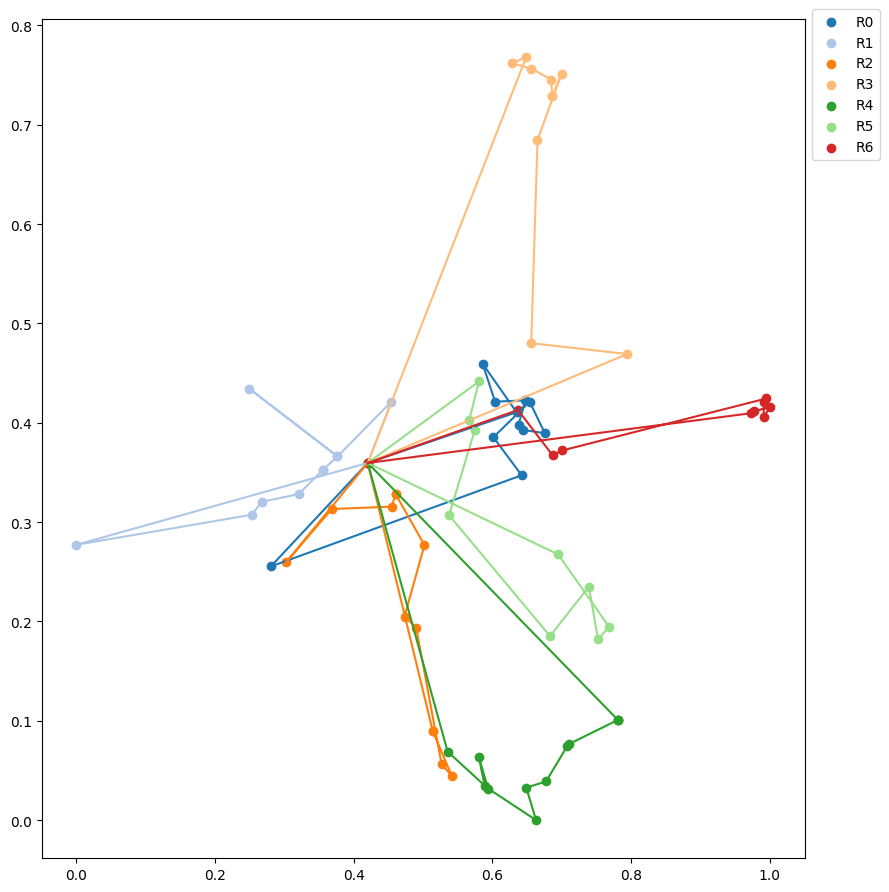

In [24]:
def route_visualize(coordinates, routes):
    coordinates = pd.DataFrame(coordinates, columns=["x", "y"])
    num_location = coordinates.shape[0]
    #
    cmap = mpl.colormaps["tab20"]
    colors = cycle(cmap.colors)
    # Now the figure
    figsize = [max(int(num_location / 8), 5), max(int(num_location / 8), 5)]
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    for r, tour in enumerate(routes):
        c = next(colors)
        t = np.array(tour)
        x = coordinates.values[t, 0]
        y = coordinates.values[t, 1]
        ax.scatter(x, y, color=c, label=f"R{r}")
        ax.plot(x, y, color=c)

    ax.legend(loc="upper left", bbox_to_anchor=(1, 1.02))
    fig.tight_layout()
    plt.show()
    return
route_visualize(td_reset[0]['locs'].tolist(), routes[0])

In [25]:
total_distances = 0
route_delivery = []
route_duration = []
for route in routes[0]:
    delivery = 0
    duration = 0
    for i in range(len(route) -1):
        total_distances += distances[route[i]][route[i+1]]
        duration += durations[route[i]][route[i+1]]
        delivery += volumes[route[i+1]]
    route_delivery.append(delivery)
    route_duration.append(duration)
print(total_distances)
print(route_delivery)
print(route_duration)

3450
[3.5534863, 1.611957315, 5.921565640000001, 0.61509651, 4.47142734, 2.140853925, 3.329559415]
[np.float64(3.8016), np.float64(3.5904000000000003), np.float64(3.8544000000000005), np.float64(4.1888000000000005), np.float64(4.1008000000000004), np.float64(4.250400000000001), np.float64(2.9656000000000002)]
